# Regresión Lineal Simple - Dataset Diabetes

En este laboratorio se implementará una regresión lineal simple para predecir los niveles de glucosa en ayunas (`glucose_fasting`) basándose en el índice de masa corporal (`bmi`).

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Cargar el dataset
df = pd.read_csv('../Database/1_diabetes_dataset.csv')

# Mostrar información general
print('Forma del dataset:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nPrimeras filas:')
df.head()

Forma del dataset: (100000, 31)

Columnas: ['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes']

Primeras filas:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
# Verificar valores nulos
print('Valores nulos por columna:')
df.isnull().sum()

Valores nulos por columna:


age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [4]:
# Estadísticas descriptivas
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [5]:
# Seleccionar variables para la regresión lineal simple
# Variable independiente (X): BMI
# Variable dependiente (y): glucose_fasting

X = df[['bmi']]
y = df['glucose_fasting']

print(f'X (BMI) forma: {X.shape}')
print(f'y (Glucosa) forma: {y.shape}')

X (BMI) forma: (100000, 1)
y (Glucosa) forma: (100000,)


In [6]:
# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño entrenamiento: {X_train.shape[0]}')
print(f'Tamaño prueba: {X_test.shape[0]}')

Tamaño entrenamiento: 80000
Tamaño prueba: 20000


In [7]:
# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado exitosamente!')
print(f'Coeficiente (β1): {modelo.coef_[0]:.4f}')
print(f'Intercepto (β0): {modelo.intercept_:.4f}')

Modelo entrenado exitosamente!
Coeficiente (β1): 0.5677
Intercepto (β0): 96.6017


In [8]:
# Realizar predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Evaluación del Modelo ===')
print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}')
print(f'Coeficiente de Determinación (R²): {r2:.4f}')

=== Evaluación del Modelo ===
Error Cuadrático Medio (MSE): 176.0030
Raíz del Error Cuadrático Medio (RMSE): 13.2666
Coeficiente de Determinación (R²): 0.0249


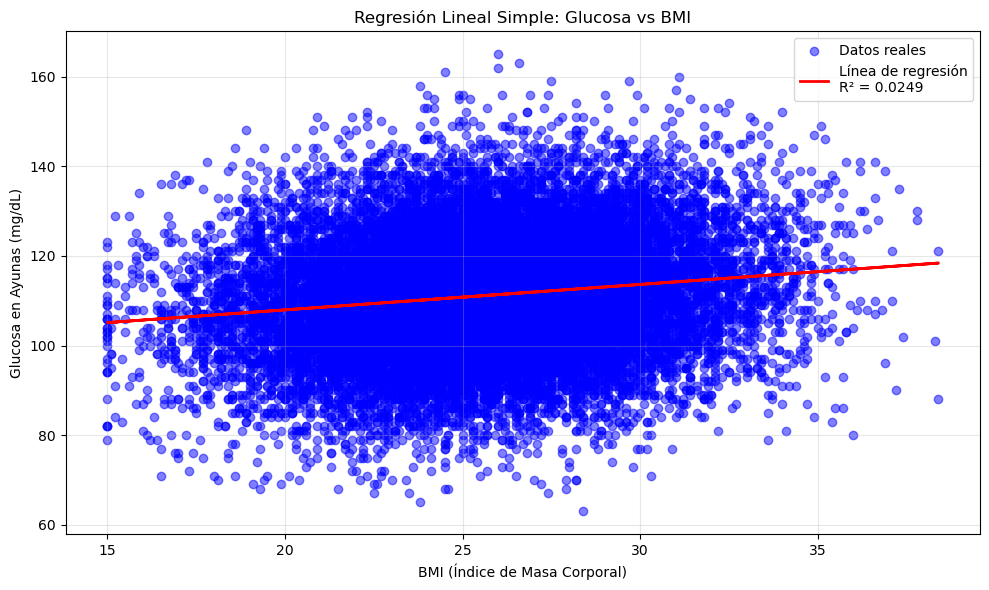

In [9]:
# Visualizar resultados
plt.figure(figsize=(10, 6))

# Dispersión de datos reales
plt.scatter(X_test, y_test, alpha=0.5, label='Datos reales', color='blue')

# Línea de regresión
plt.plot(X_test, y_pred, color='red', linewidth=2, label=f'Línea de regresión\nR² = {r2:.4f}')

plt.xlabel('BMI (Índice de Masa Corporal)')
plt.ylabel('Glucosa en Ayunas (mg/dL)')
plt.title('Regresión Lineal Simple: Glucosa vs BMI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

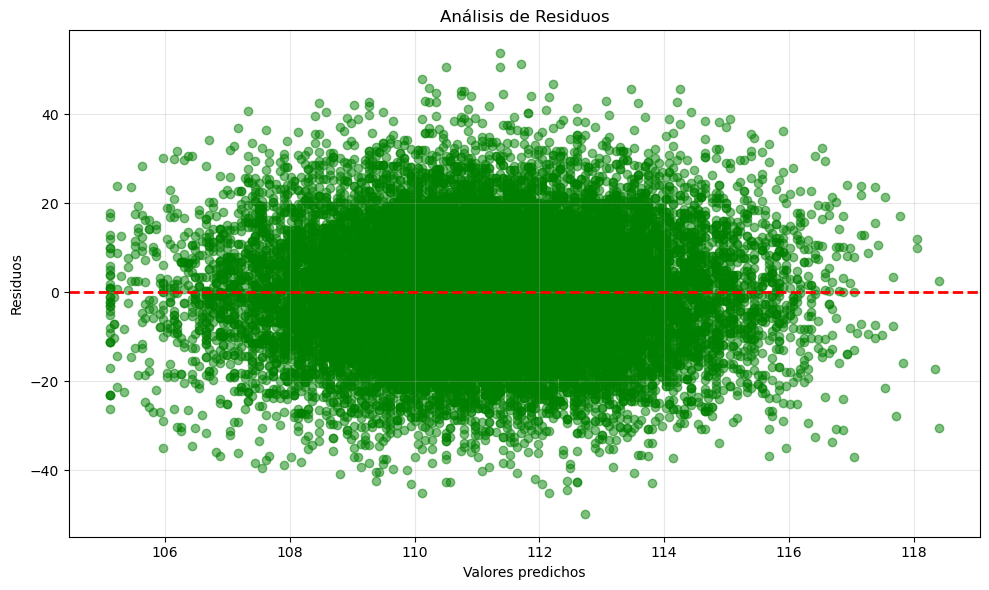

In [10]:
# Visualizar residuos
plt.figure(figsize=(10, 6))
residuos = y_test - y_pred

plt.scatter(y_pred, residuos, alpha=0.5, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Mostrar ecuación del modelo
print('=== Ecuación de Regresión ===')
print(f'glucose_fasting = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} * bmi')
print('\nInterpretación:')
print(f'- Por cada unidad de aumento en el BMI, la glucosa en ayunas aumenta en {modelo.coef_[0]:.4f} mg/dL')
print(f'- El valor base (cuando BMI = 0) sería de {modelo.intercept_:.4f} mg/dL')

=== Ecuación de Regresión ===
glucose_fasting = 96.6017 + 0.5677 * bmi

Interpretación:
- Por cada unidad de aumento en el BMI, la glucosa en ayunas aumenta en 0.5677 mg/dL
- El valor base (cuando BMI = 0) sería de 96.6017 mg/dL
